In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Path to your dataset
dataset_path = "/content/drive/MyDrive/dataset-resized"

# Optional: Check class directories
print(os.listdir(dataset_path))


['paper', 'trash', 'plastic', 'cardboard', 'metal', 'glass']


In [ ]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,       # normalize pixel values
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% for validation
)

# Training data
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2034 images belonging to 6 classes.
Found 506 images belonging to 6 classes.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(6, activation='sigmoid')  # 7 multilabel classes
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25
)


Epoch 1/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 790s 12s/step - accuracy: 0.3444 - loss: 1.7953 - val_accuracy: 0.2253 - val_loss: 2.0413
Epoch 2/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 310ms/step - accuracy: 0.4862 - loss: 1.2940 - val_accuracy: 0.2688 - val_loss: 2.9300
Epoch 3/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 323ms/step - accuracy: 0.5576 - loss: 1.2032 - val_accuracy: 0.1858 - val_loss: 2.9284
Epoch 4/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 310ms/step - accuracy: 0.5774 - loss: 1.1671 - val_accuracy: 0.2036 - val_loss: 3.2293
Epoch 5/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 329ms/step - accuracy: 0.6080 - loss: 1.0653 - val_accuracy: 0.1957 - val_loss: 3.4558
Epoch 6/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.6283 - loss: 1.0468 - val_accuracy: 0.2134 - val_loss: 4.8931
Epoch 7/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step - accuracy: 0.6089 - loss: 1.0303 - val_accuracy: 0.2945 - val_loss: 3.1071
Epoch 8/25
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 327ms/step - accuracy: 0.6151 - loss: 1.0407 - val_accur

In [ ]:
# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# Predict on new images
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/drive/MyDrive/dataset-resized/plastic/plastic112.jpg"
img = image.load_img(img_path, target_size=(128,128))
x = image.img_to_array(img)/255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)
class_index = np.argmax(pred)
print("Predicted class:", list(train_generator.class_indices.keys())[class_index])


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - accuracy: 0.4671 - loss: 1.8436
Validation Accuracy: 44.47%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted class: plastic


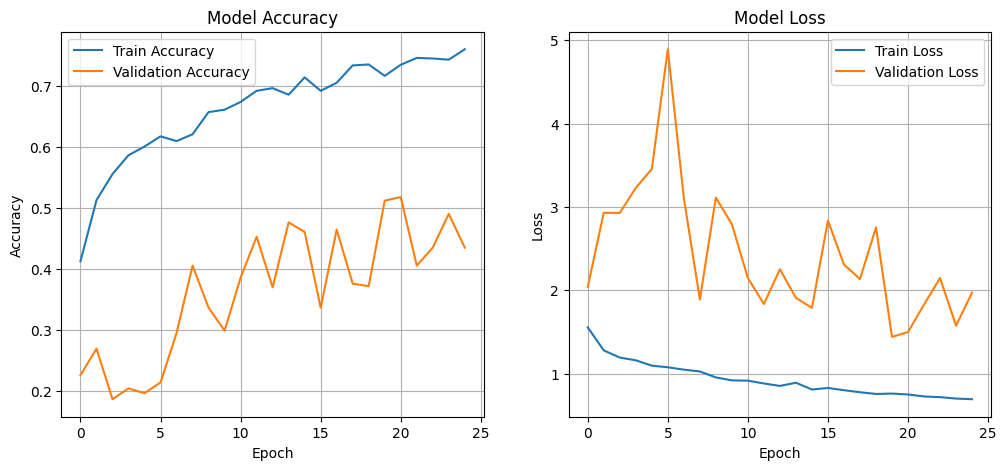

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 242ms/step


<Figure size 800x600 with 0 Axes>

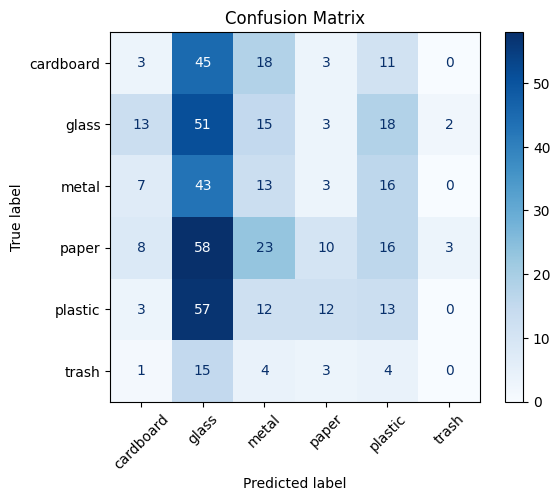

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
val_generator.reset()  # make sure generator is at start
Y_true = val_generator.classes
Y_pred_prob = model.predict(val_generator)
Y_pred = np.argmax(Y_pred_prob, axis=1)

# Compute confusion matrix
cm = confusion_matrix(Y_true, Y_pred)
class_names = list(val_generator.class_indices.keys())

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8,6))
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
